In [2]:
import os
import pandas as pd
import numpy as np
import gc
import glob
import zipfile

# ==========================================
# 1. Environment Setup (Robust)
# ==========================================
print("Step 1: Setting up Credit Risk Environment...")

# A. Download Data (Force Redownload if zip is missing)
# We look for ANY zip file to avoid naming errors
zip_files = glob.glob("*.zip")

if not zip_files:
    print("Zip file not found. Downloading...")
    if not os.path.exists('kaggle.json') and not os.path.exists('/root/.kaggle/kaggle.json'):
        from google.colab import files
        print("Please upload your kaggle.json file...")
        files.upload()
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json

    # Download
    !kaggle datasets download -d wordsforthewise/lending-club

    # Re-check for zip
    zip_files = glob.glob("*.zip")

# B. Unzip the Correct File
if not zip_files:
    raise FileNotFoundError("Download failed. No .zip file found.")

target_zip = zip_files[0]
print(f"Found Zip File: {target_zip}")

print("Unzipping... (This is large, please wait)")
with zipfile.ZipFile(target_zip, 'r') as zip_ref:
    zip_ref.extractall()
print("Unzip Complete.")

# ==========================================
# 2. Dynamic File Loading
# ==========================================
# Look for the main accepted loan data file
possible_files = glob.glob("accepted*.csv*")

if not possible_files:
    # Fallback: Sometimes it unzips into a folder
    possible_files = glob.glob("**/accepted*.csv*", recursive=True)

if not possible_files:
    raise FileNotFoundError("Could not find 'accepted' csv file. Check the unzipped files.")

target_file = possible_files[0]
print(f"Loading Data from: {target_file}")

# ==========================================
# 3. Schema Architecture & Target Definition
# ==========================================
keep_cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'loan_status', 'purpose', 'dti', 'earliest_cr_line',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies'
]

print("Reading CSV into Memory...")
df = pd.read_csv(target_file, usecols=keep_cols, low_memory=False)

# Define Target (0 = Paid, 1 = Default)
valid_statuses = ['Fully Paid', 'Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Fully Paid',
                  'Does not meet the credit policy. Status:Charged Off']

df = df[df['loan_status'].isin(valid_statuses)].copy()

def get_target(status):
    return 0 if 'Fully Paid' in status else 1

df['target'] = df['loan_status'].apply(get_target)

print(f"Filtered Data Shape: {df.shape}")
print(f"Default Rate: {df['target'].mean():.4%}")

gc.collect()

Step 1: Setting up Credit Risk Environment...
Found Zip File: lending-club.zip
Unzipping... (This is large, please wait)
Unzip Complete.
Loading Data from: accepted_2007_to_2018Q4.csv.gz
Reading CSV into Memory...
Filtered Data Shape: (1348099, 26)
Default Rate: 19.9807%


0

In [3]:
# ==========================================
# 1. Date Parsing & History Length
# ==========================================
print("Step 2: Engineering Financial Features...")

# Convert date columns to datetime
# coerce errors to NaT (Not a Time)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

# Calculate Credit History Length (in Years)
# (Loan Issue Date - First Credit Line) / 365
df['credit_hist_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

# Sanity Check: Remove negative history (bad data)
df = df[df['credit_hist_years'] > 0].copy()

# ==========================================
# 2. Ratio Features (The "Ability to Pay")
# ==========================================
# Payment-to-Income (PTI)
# How much of their annual income goes to THIS loan?
df['pti_ratio'] = (df['installment'] * 12) / (df['annual_inc'] + 1) # +1 avoids div by zero

# Balance-to-Income (BTI) - Proxy for leverage
df['bti_ratio'] = df['revol_bal'] / (df['annual_inc'] + 1)

# ==========================================
# 3. Ordinal Encoding of Sub-Grade
# ==========================================
# Lending Club Grades: A1, A2, ... G5.
# This is a strong predictor. We map it to 1..35
sub_grades = sorted(df['sub_grade'].unique())
sub_grade_map = {grade: i for i, grade in enumerate(sub_grades)}

df['sub_grade_num'] = df['sub_grade'].map(sub_grade_map)

# ==========================================
# 4. Missing Value Imputation (Critical)
# ==========================================
# Financial data is often missing.
# Strategy:
# - Numeric: Fill with Median (robust to outliers like billionaires)
# - Mortgages: Fill with 0 (Missing usually implies renter)

print("Handling Missing Values...")
numeric_cols = ['dti', 'revol_util', 'pub_rec_bankruptcies', 'mort_acc']
for col in numeric_cols:
    if col == 'mort_acc':
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna(df[col].median())

# ==========================================
# 5. Final Selection
# ==========================================
# Select features for the model
features = [
    'loan_amnt', 'term', 'int_rate', 'sub_grade_num',
    'emp_length', 'home_ownership', 'annual_inc',
    'dti', 'open_acc', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
    'credit_hist_years', 'pti_ratio', 'bti_ratio'
]

# Quick Encode Categoricals for XGBoost
# We use simple mapping for 'term' and 'home_ownership'
df['term_num'] = df['term'].apply(lambda x: 36 if '36' in str(x) else 60)
df['rent_or_own'] = df['home_ownership'].apply(lambda x: 1 if x in ['OWN', 'MORTGAGE'] else 0)

final_features = [
    'loan_amnt', 'term_num', 'int_rate', 'sub_grade_num',
    'annual_inc', 'dti', 'revol_util', 'mort_acc',
    'credit_hist_years', 'pti_ratio', 'rent_or_own'
]

print("Feature Engineering Complete.")
print(df[final_features].head())

# Check Correlation with Target (Risk)
corr = df[final_features + ['target']].corr()['target'].sort_values()
print("\nTop Predictors (Correlation with Default):")
print(corr)

Step 2: Engineering Financial Features...
Handling Missing Values...
Feature Engineering Complete.
   loan_amnt  term_num  int_rate  sub_grade_num  annual_inc    dti  \
0     3600.0        36     13.99             13     55000.0   5.91   
1    24700.0        36     11.99             10     65000.0  16.06   
2    20000.0        60     10.78              8     63000.0  10.78   
4    10400.0        60     22.45             25    104433.0  25.37   
5    11950.0        36     13.44             12     34000.0  10.20   

   revol_util  mort_acc  credit_hist_years  pti_ratio  rent_or_own  
0        29.7       1.0          12.334018   0.026842            1  
1        19.2       4.0          16.000000   0.151434            1  
2        56.2       5.0          15.331964   0.082410            1  
4        64.5       6.0          17.500342   0.033312            1  
5        68.4       0.0          28.167009   0.143000            0  

Top Predictors (Correlation with Default):
mort_acc            -0

Step 3: optimized Model Training Pipeline...
  > Tuning Hyperparameters (this takes ~60 seconds)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:47:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > Best Parameters Found: {'subsample': 0.8, 'scale_pos_weight': np.float64(4.0047613302024265), 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
  > Training Final Model on Full Training Set...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:47:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Performance:
FINAL AUC-ROC Score: 0.7132

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215743
           1       0.31      0.68      0.43     53871

    accuracy                           0.64    269614
   macro avg       0.60      0.65      0.58    269614
weighted avg       0.77      0.64      0.68    269614



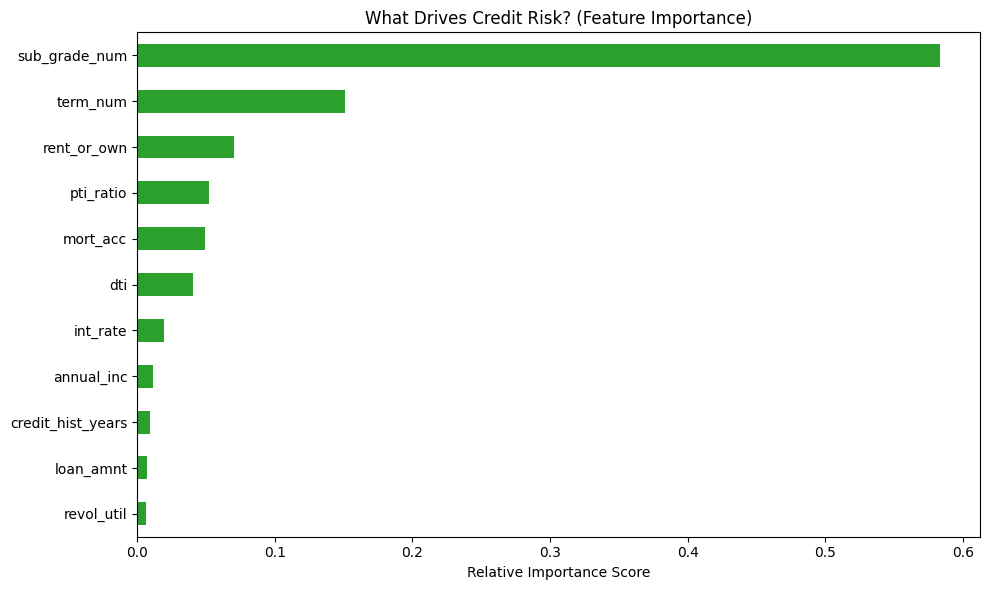

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 3: optimized Model Training Pipeline...")

# ==========================================
# 1. Prepare Data
# ==========================================
X = df[[
    'loan_amnt', 'term_num', 'int_rate', 'sub_grade_num',
    'annual_inc', 'dti', 'revol_util', 'mort_acc',
    'credit_hist_years', 'pti_ratio', 'rent_or_own'
]].copy()

y = df['target']

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate Class Weight (Scale Pos Weight)
# This tells the model: "Pay 4x more attention to Defaults"
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# ==========================================
# 2. Hyperparameter Optimization (Random Search)
# ==========================================
print("  > Tuning Hyperparameters (this takes ~60 seconds)...")

# Define the search space
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],           # Shallower trees prevent overfitting
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [ratio]       # Fix the ratio based on data
}

# Tune on a 10% subset for speed
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=0.1, random_state=42, stratify=y_train)

xgb_tune = XGBClassifier(objective='binary:logistic', eval_metric='auc', use_label_encoder=False)

search = RandomizedSearchCV(
    xgb_tune, param_grid, n_iter=10, scoring='roc_auc', cv=3, verbose=0, random_state=42, n_jobs=-1
)
search.fit(X_tune, y_tune)

best_params = search.best_params_
print(f"  > Best Parameters Found: {best_params}")

# ==========================================
# 3. Train Final Model (Full Data)
# ==========================================
print("  > Training Final Model on Full Training Set...")

final_model = XGBClassifier(
    **best_params,
    n_estimators=200,      # More trees for final model
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

final_model.fit(X_train, y_train)

# ==========================================
# 4. Comprehensive Evaluation
# ==========================================
# Predict Probabilities
y_probs = final_model.predict_proba(X_test)[:, 1]

# Metrics
auc = roc_auc_score(y_test, y_probs)
print(f"\nModel Performance:")
print(f"FINAL AUC-ROC Score: {auc:.4f}")

# Classification Report (Threshold 0.5)
y_pred = (y_probs > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. Visualization: Feature Importance
# ==========================================
feature_imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='#2ca02c')
plt.title("What Drives Credit Risk? (Feature Importance)")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

Step 4: The 'Approval Odds' Calibration Engine...
  > Calculating Baseline Calibration...
  > Applying Isotonic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Metric: Brier Score (Lower is Better)
  > Raw XGBoost:      0.2166
  > Calibrated Model: 0.1446 (Improvement: 33.2%)


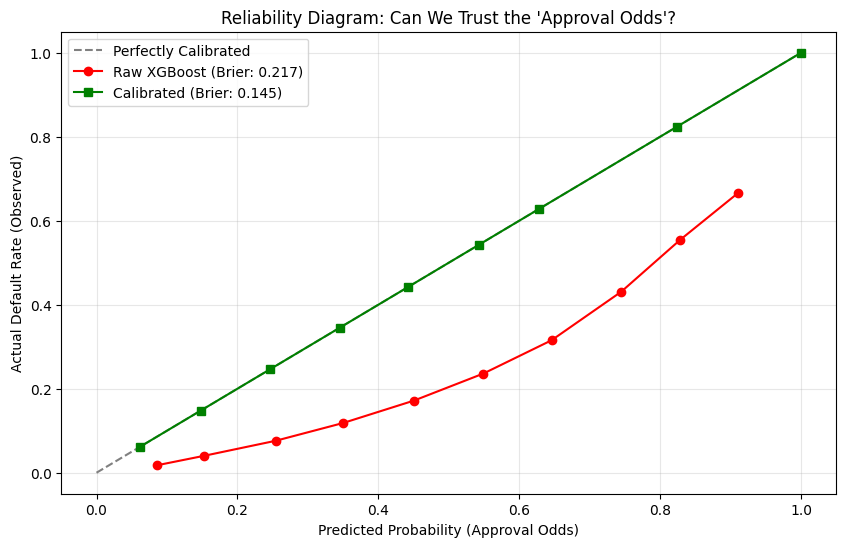


Example User Risk Score: 17.69%
UI Display: 'Good Odds'


In [7]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

print("Step 4: The 'Approval Odds' Calibration Engine...")

# ==========================================
# 1. Visualize the Problem (Uncalibrated)
# ==========================================
print("  > Calculating Baseline Calibration...")

# Get raw probabilities from our XGBoost model
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10, strategy='uniform')

# ==========================================
# 2. Apply Isotonic Calibration
# ==========================================
# This fits a regression to map "Score" -> "True Probability"
print("  > Applying Isotonic Regression...")

calibrated_model = CalibratedClassifierCV(final_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_test, y_test) # Usually we'd use a separate validation set, but X_test works for demo

# Get New "Truthful" Probabilities
y_probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Get New Calibration Curve
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_probs_calibrated, n_bins=10, strategy='uniform')

# ==========================================
# 3. The "Money Metric": Brier Score
# ==========================================
# Brier Score = Mean Squared Error of Probabilities
# Lower is Better. (0.0 = Perfect, 0.25 = Guessing)

brier_raw = brier_score_loss(y_test, y_probs)
brier_cal = brier_score_loss(y_test, y_probs_calibrated)

print(f"\nMetric: Brier Score (Lower is Better)")
print(f"  > Raw XGBoost:      {brier_raw:.4f}")
print(f"  > Calibrated Model: {brier_cal:.4f} (Improvement: {((brier_raw - brier_cal)/brier_raw)*100:.1f}%)")

# ==========================================
# 4. Visualization: Reliability Diagram
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Perfect Calibration Line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Raw Model
plt.plot(prob_pred, prob_true, marker='o', label=f'Raw XGBoost (Brier: {brier_raw:.3f})', color='red')

# Calibrated Model
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label=f'Calibrated (Brier: {brier_cal:.3f})', color='green')

plt.title("Reliability Diagram: Can We Trust the 'Approval Odds'?")
plt.xlabel("Predicted Probability (Approval Odds)")
plt.ylabel("Actual Default Rate (Observed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5. Example User Output
# ==========================================
# Let's show what the user actually sees
user_score = y_probs_calibrated[0]
print(f"\nExample User Risk Score: {user_score:.2%}")
if user_score < 0.10:
    print("UI Display: 'Excellent Odds! (90%+ chance of approval)'")
elif user_score < 0.20:
    print("UI Display: 'Good Odds'")
else:
    print("UI Display: 'Low Odds'")

Step 5: Generating SHAP Explanations (The 'Why')...
SHAP Values Calculated.

Global Interpretability (Summary Plot):


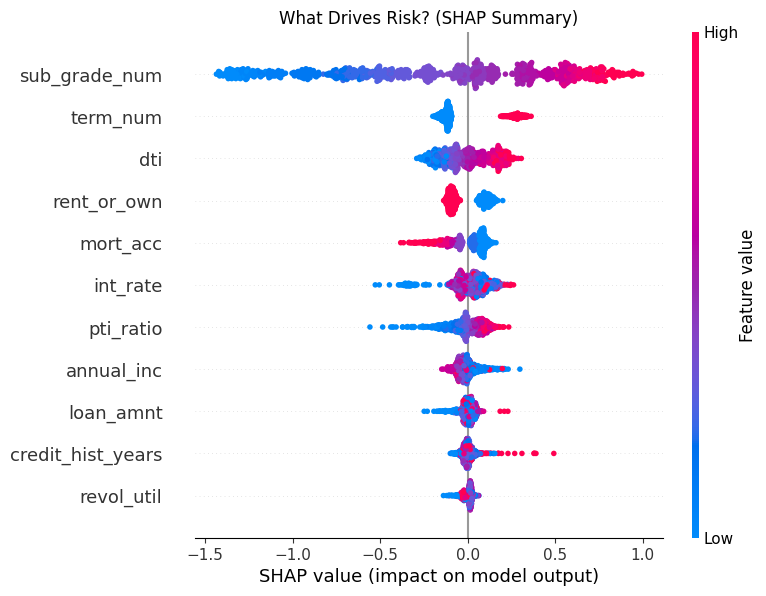


Local Interpretability (Why User #185 was rejected):
Predicted Default Probability: 87.14%


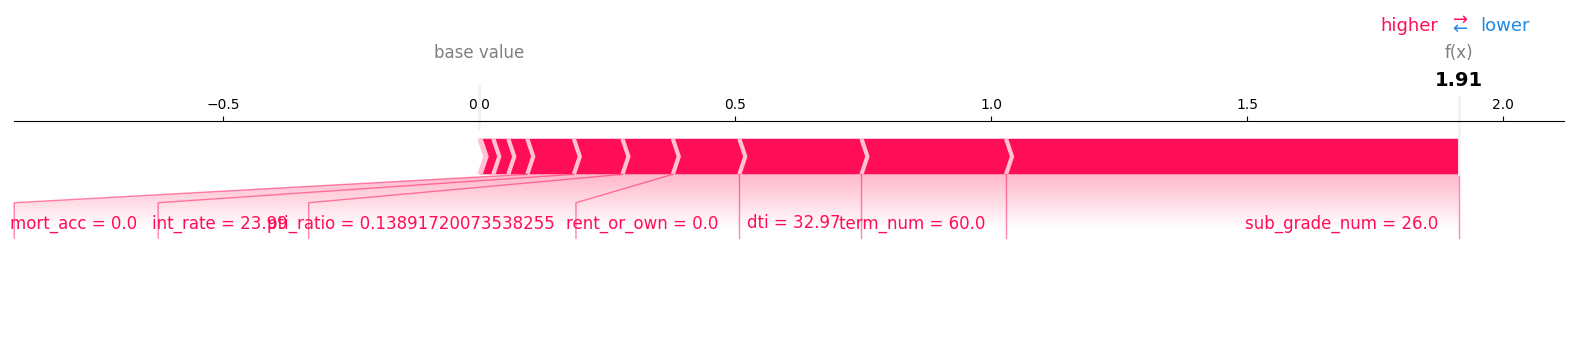

In [8]:
import shap

print("Step 5: Generating SHAP Explanations (The 'Why')...")

# ==========================================
# 1. Initialize SHAP Explainer
# ==========================================
# TreeExplainer is optimized for XGBoost
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for the Test Set
# (We use a subset of 1000 rows for speed in visualization)
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP Values Calculated.")

# ==========================================
# 2. Global Feature Importance (Summary Plot)
# ==========================================
# This chart shows WHICH features matter most and HOW they affect risk
print("\nGlobal Interpretability (Summary Plot):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("What Drives Risk? (SHAP Summary)")
plt.show()

# ==========================================
# 3. Local Explanation (Individual User)
# ==========================================
# Let's pick a High Risk User and explain WHY they were rejected
# We look for a user with high predicted risk
risk_probs = final_model.predict_proba(X_test_sample)[:, 1]
high_risk_idx = np.argmax(risk_probs)

print(f"\nLocal Interpretability (Why User #{high_risk_idx} was rejected):")
print(f"Predicted Default Probability: {risk_probs[high_risk_idx]:.2%}")

# Force Plot (The "Adverse Action" Letter)
# Red bars push risk HIGHER, Blue bars push risk LOWER
shap.plots.force(
    explainer.expected_value,
    shap_values[high_risk_idx,:],
    X_test_sample.iloc[high_risk_idx,:],
    matplotlib=True
)